In [1]:
from my_implementation.utils.paths import get_results_root, list_available_runs
from my_implementation.analysis.plotting import plot_training_comparison
from my_implementation.analysis.summary import summary_table
from my_implementation.utils.paths import get_results_root, get_videos_dir
from my_implementation.analysis.render import render_run_video

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


MyoSuite:> Registering Myo Envs


In [2]:
results_root = get_results_root()
eval_logs_dir = results_root / "eval_logs"
checkpoints_dir = results_root / "checkpoints"

run_names = list_available_runs(eval_logs_dir)
print(f"Runs disponibles : {run_names}")


Runs disponibles : ['initR_sparse0_solved_10_qpos30_fwd10_alive15_fallM20']


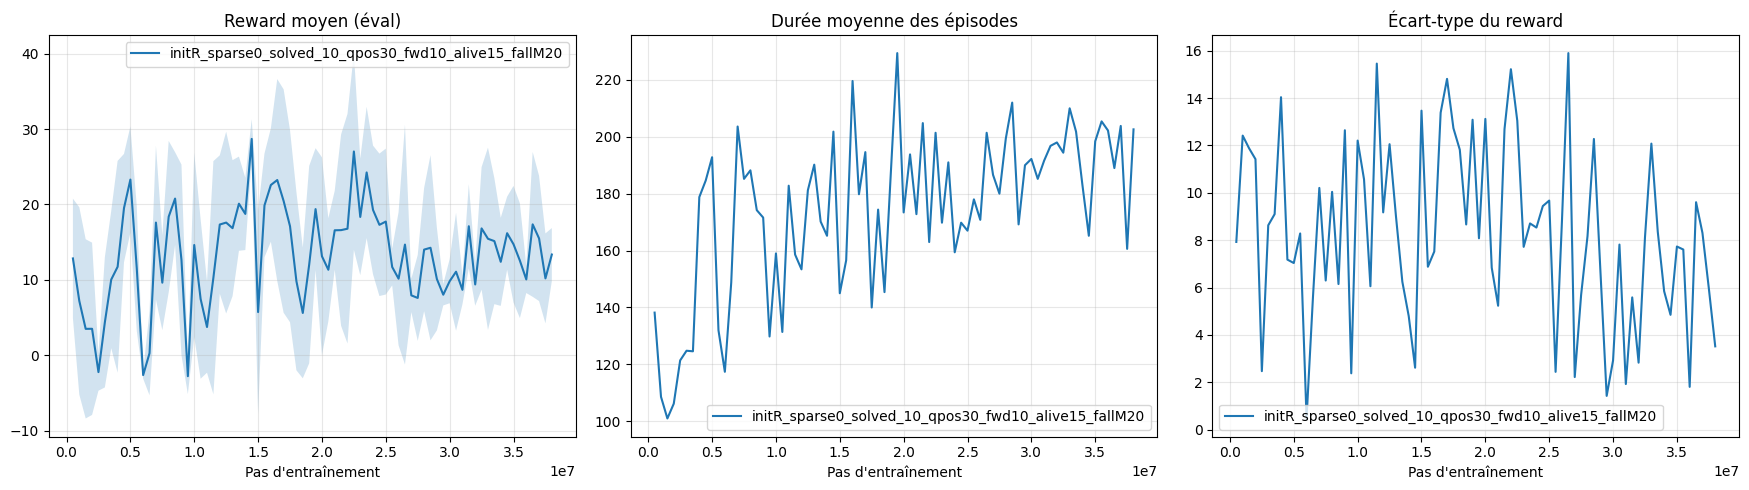

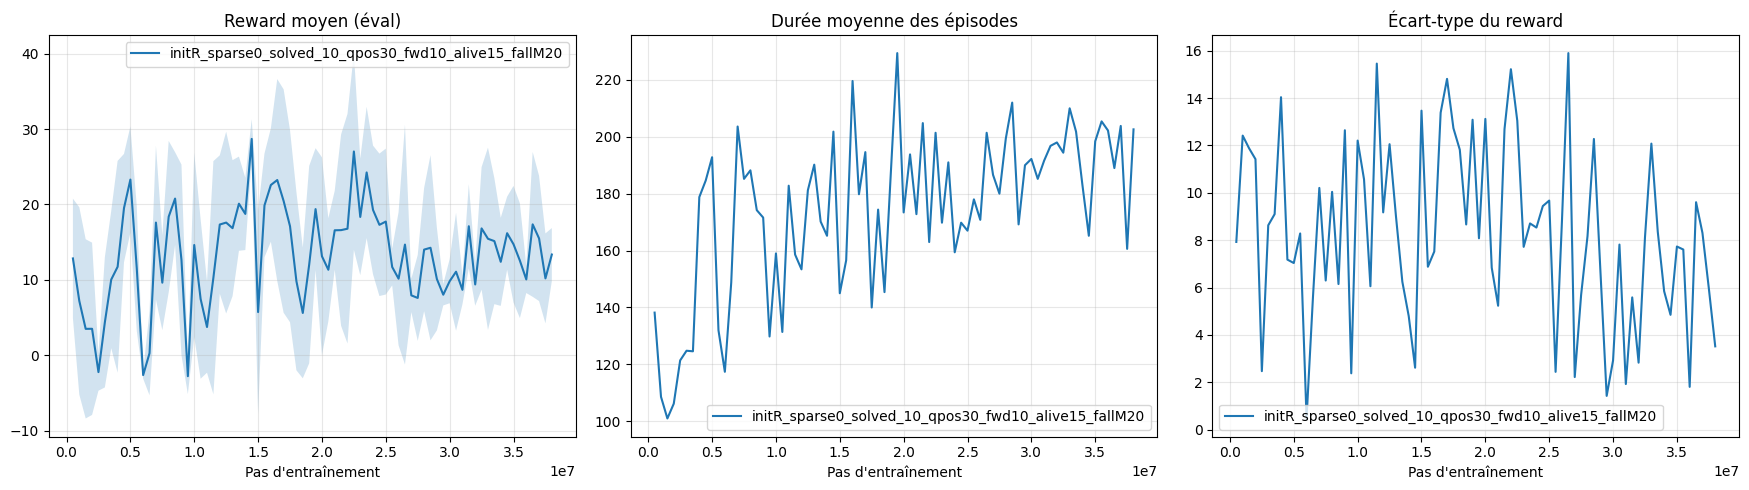

In [3]:
plot_training_comparison(run_names, eval_logs_dir, results_root / "training_comparison.png")


In [4]:
summary_table(run_names, checkpoints_dir, results_root / "summary.csv")

Évaluation de initR_sparse0_solved_10_qpos30_fwd10_alive15_fallM20 (checkpoint: initR_sparse0_solved_10_qpos30_fwd10_alive15_fallM20_38000000_steps.zip)...
    MyoSuite: A contact-rich simulation suite for musculoskeletal motor control
        Vittorio Caggiano, Huawei Wang, Guillaume Durandau, Massimo Sartori, Vikash Kumar
        L4DC-2019 | https://sites.google.com/view/myosuite
    


c:\Users\ST000082\Documents\Codes\myosuite-soph\.venv\Lib\site-packages\gymnasium\spaces\box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
c:\Users\ST000082\Documents\Codes\myosuite-soph\.venv\Lib\site-packages\gymnasium\spaces\box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
c:\Users\ST000082\Documents\Codes\myosuite-soph\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
c:\Users\ST000082\Documents\Codes\myosuite-soph\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


[RunTrackImitation] Vitesse cible d'avancée calculée depuis le CSV : 1.2421 m/s
                                                    distance_mean  \
run_name                                                            
initR_sparse0_solved_10_qpos30_fwd10_alive15_fa...      14.452161   

                                                    distance_std  ep_len_mean  \
run_name                                                                        
initR_sparse0_solved_10_qpos30_fwd10_alive15_fa...      0.302708       171.05   

                                                    ep_len_std  fall_rate  \
run_name                                                                    
initR_sparse0_solved_10_qpos30_fwd10_alive15_fa...   23.923785        0.0   

                                                                                           checkpoint  
run_name                                                                                               
initR_sparse0_solved_10_qpos

,distance_mean,distance_std,ep_len_mean,ep_len_std,fall_rate,checkpoint
run_name,,,,,,
initR_sparse0_solved_10_qpos30_fwd10_alive15_fallM20,14.452161,0.302708,171.05,23.923785,0.0,initR_sparse0_solved_10_qpos30_fwd10_alive15_f...


In [5]:
results_root = get_results_root()
run_name = "initR_sparse0_solved_10_qpos30_fwd10_alive15_fallM20"
weighted_reward_keys = {"sparse": 1, "solved": 10, "qpos_imitation": 40}

best_model_path = results_root / "checkpoints" / run_name / "best_model.zip"
final_model_path = results_root / "checkpoints" / f"{run_name}_final.zip"
model_path = best_model_path if best_model_path.exists() else final_model_path
print(f"Chargement du modèle depuis : {model_path}")

render_run_video(
    weighted_reward_keys=weighted_reward_keys,
    model_path=str(model_path),
    savepath=str(get_videos_dir() / f"{run_name}.mp4"),
)

c:\Users\ST000082\Documents\Codes\myosuite-soph\.venv\Lib\site-packages\gymnasium\spaces\box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
c:\Users\ST000082\Documents\Codes\myosuite-soph\.venv\Lib\site-packages\gymnasium\spaces\box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Chargement du modèle depuis : C:\Users\ST000082\OneDrive - Vrije Universiteit Brussel\05-PredictiveSimulations\01-MyoSuite\results\checkpoints\initR_sparse0_solved_10_qpos30_fwd10_alive15_fallM20\best_model.zip
[RunTrackImitation] Vitesse cible d'avancée calculée depuis le CSV : 1.2421 m/s
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


  0%|          | 0/5 [00:00<?, ?it/s]c:\Users\ST000082\Documents\Codes\myosuite-soph\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
c:\Users\ST000082\Documents\Codes\myosuite-soph\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
 20%|██        | 1/5 [00:07<00:31,  7.88s/it]

Episode 0: reward=67.96, steps=92


 40%|████      | 2/5 [00:23<00:37, 12.60s/it]

Episode 1: reward=-44.69, steps=182


 40%|████      | 2/5 [00:28<00:42, 14.07s/it]


KeyboardInterrupt: 